In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [9]:
X,y = make_blobs(n_samples=500, centers=3, cluster_std=4,random_state=42)

In [11]:
df = pd.DataFrame(X,columns=['Feature_1','Feature_2'])
df.head()

,Feature_1,Feature_2
0,-2.282534,-9.692815
1,-6.147668,1.755990
2,13.399091,-1.260023
3,-4.077630,3.160226
4,9.444735,0.340868


In [16]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

In [17]:
X_scaled

array([[-1.21708433e-01, -1.50453612e+00],
       [-7.62148118e-01,  3.13871208e-02],
       [ 2.47668402e+00, -3.73228495e-01],
       [-4.19149863e-01,  2.19773488e-01],
       [ 1.82146052e+00, -1.58459654e-01],
       [ 1.57564750e+00, -3.98871317e-01],
       [ 8.13358266e-01, -1.17874339e+00],
       [ 1.20456723e+00,  3.35640701e-02],
       [ 3.17707619e-01, -1.58811160e-02],
       [-1.29755269e+00, -1.11319438e+00],
       [ 5.96772270e-01, -5.19860592e-01],
       [ 6.08635717e-01,  5.64732296e-01],
       [ 1.25447998e+00, -4.24059660e-02],
       [ 2.19112701e-01,  1.61450005e+00],
       [ 1.21737096e+00,  1.17423091e+00],
       [ 1.72682160e+00, -8.83257153e-01],
       [-2.06993192e-01,  1.54364823e+00],
       [-1.62755640e+00, -9.21985553e-01],
       [-8.28894617e-01, -5.55434108e-01],
       [-8.92529795e-01,  3.63217297e-01],
       [ 9.83603020e-02,  3.62625267e-01],
       [-2.08338702e-02, -4.64748160e-02],
       [ 1.40744628e+00,  2.27547005e-01],
       [ 1.

In [18]:
WCSS = []
K_range  = range(1,11)

In [20]:
for k in K_range:
  kmeans = KMeans(n_clusters=k,random_state=42)
  kmeans.fit(X_scaled)
  WCSS.append(kmeans.inertia_)

In [21]:
WCSS

[999.9999999999994,
 528.8064432605643,
 294.4377068678185,
 250.4552469653445,
 216.88110656982604,
 185.27440675195913,
 156.70879996290438,
 135.62603453115264,
 129.1039634823981,
 119.94101297104991]

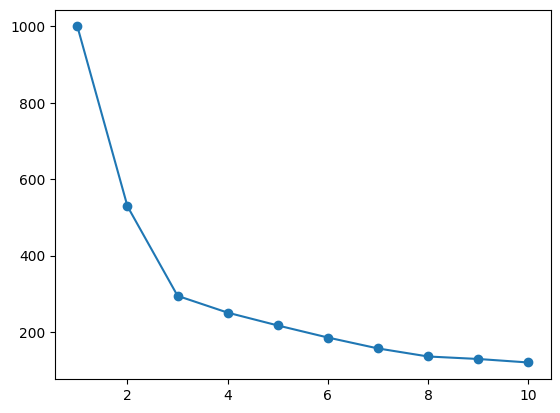

In [24]:
plt.plot(K_range , WCSS,marker='o')

In [26]:
k_means_final = KMeans(n_clusters=3,random_state=42)
k_means_final

KMeans(n_clusters=3, random_state=42)

In [28]:
cluster_labels = k_means_final.fit_predict(X_scaled)
cluster_labels

array([1, 2, 0, 2, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 2, 1, 1, 2, 2, 2,
       0, 1, 1, 0, 0, 1, 1, 2, 0, 2, 2, 2, 0, 0, 0, 2, 1, 1, 0, 2, 2, 2,
       0, 0, 0, 0, 0, 1, 1, 2, 1, 1, 0, 2, 2, 1, 0, 1, 1, 2, 0, 1, 0, 1,
       0, 1, 2, 0, 0, 0, 0, 1, 2, 1, 0, 0, 2, 2, 1, 2, 0, 2, 1, 1, 1, 2,
       0, 2, 1, 0, 2, 0, 0, 1, 2, 2, 2, 1, 0, 2, 0, 1, 1, 2, 2, 1, 2, 1,
       1, 1, 2, 1, 1, 2, 2, 1, 0, 1, 2, 2, 0, 0, 0, 0, 2, 0, 1, 1, 1, 0,
       2, 1, 0, 1, 1, 1, 1, 2, 1, 1, 0, 0, 1, 1, 1, 2, 2, 2, 0, 1, 0, 2,
       2, 1, 2, 1, 0, 0, 0, 1, 2, 2, 1, 2, 2, 0, 1, 1, 1, 2, 2, 1, 1, 2,
       2, 2, 0, 0, 2, 1, 0, 2, 1, 1, 0, 0, 2, 1, 1, 1, 1, 1, 2, 0, 2, 2,
       1, 0, 2, 0, 1, 1, 0, 1, 1, 2, 2, 1, 1, 0, 1, 2, 2, 1, 2, 1, 2, 0,
       2, 2, 1, 2, 0, 2, 2, 1, 0, 0, 0, 0, 2, 1, 1, 1, 2, 0, 2, 0, 0, 1,
       2, 2, 1, 1, 0, 2, 2, 0, 2, 0, 2, 2, 0, 2, 1, 2, 0, 2, 2, 2, 1, 2,
       0, 0, 0, 2, 0, 0, 2, 2, 0, 1, 2, 2, 2, 2, 1, 1, 0, 0, 2, 2, 1, 2,
       0, 1, 0, 0, 1, 2, 2, 2, 1, 2, 1, 2, 0, 0, 0,

In [29]:
df['cluster'] = cluster_labels

<Axes: xlabel='Feature_1', ylabel='Feature_2'>

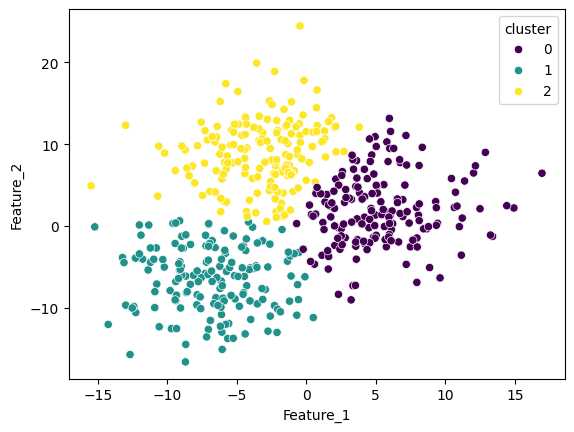

In [31]:
sns.scatterplot(x=df['Feature_1'],y=df['Feature_2'],hue=df['cluster'],palette='viridis')

In [32]:
from sklearn.datasets import make_moons

In [33]:
X,y = make_moons(n_samples=500,noise=0.05,random_state=42)

In [37]:
df_kmeans = pd.DataFrame(X,columns=['Feature_1','Feature_2'])
df_kmeans.head()

,Feature_1,Feature_2
0,0.830586,-0.447733
1,0.701678,0.816918
2,1.022080,-0.492571
3,-0.316765,0.953438
4,0.293226,1.057185


In [38]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_kmeans)

In [57]:
kmeans_final = KMeans(n_clusters=2,random_state=42)
cluster_labels_new = kmeans_final.fit_predict(X_scaled)

In [58]:
df_kmeans['k_means_cluster'] = cluster_labels_new

<Axes: xlabel='Feature_1', ylabel='Feature_2'>

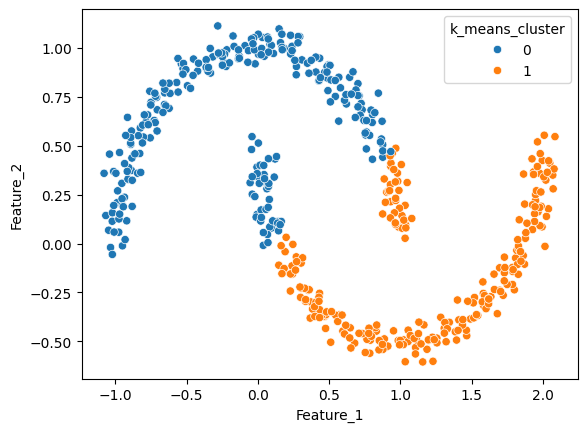

In [59]:
sns.scatterplot(x=df_kmeans['Feature_1'],y=df_kmeans['Feature_2'],hue=df_kmeans['k_means_cluster'],palette='tab10')

In [61]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.5,min_samples=3)
cluster_labels_dbscan = dbscan.fit_predict(X_scaled)

In [65]:
df_kmeans['dbscan_cluster'] = cluster_labels_dbscan

<Axes: xlabel='Feature_1', ylabel='Feature_2'>

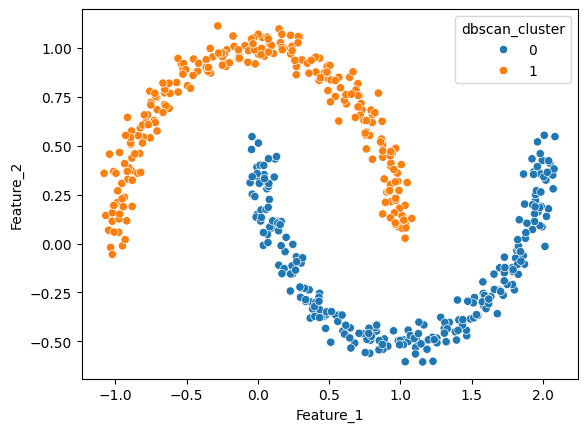

In [67]:
sns.scatterplot(x=df_kmeans['Feature_1'],y=df_kmeans['Feature_2'],hue=df_kmeans['dbscan_cluster'],palette='tab10')